# Levenshtein Distance: Edit Distance with Dynamic Programming

Levenshtein distance answers one question:

> How many single-character edits does it take to turn one string into another?

Vladimir Levenshtein introduced this distance in the 1960s while studying error-correcting codes. Today the same idea appears in spell checkers, search suggestions, DNA sequence comparison, translation tools, and fuzzy matching.

Allowed edits:

- insert a character,
- delete a character,
- substitute one character for another.

For example, `kitten` to `sitting` has distance `3`: substitute `k -> s`, substitute `e -> i`, insert `g`.

## 1. Mental Model

Imagine every cell in a grid is a tiny problem:

> What is the edit distance between a prefix of word A and a prefix of word B?

Rows are prefixes of the source word. Columns are prefixes of the target word.

If you already solved the neighboring smaller prefixes, the current cell only has three choices:

- delete from the source,
- insert into the source,
- substitute or match the next character.

<details>
<summary>Why this is dynamic programming</summary>

The same prefix comparisons show up again and again. Dynamic programming stores those answers in a table so each sub-problem is solved once.
</details>

## 2. The Recurrence

Let `dp[row][col]` mean:

> distance between `source[:row]` and `target[:col]`

Base cases:

- `dp[row][0] = row`, because turning a prefix into empty text needs deletions.
- `dp[0][col] = col`, because turning empty text into a prefix needs insertions.

Transition:

$$
dp[row][col] = \min\begin{cases}
dp[row-1][col] + 1 & \text{delete} \\
dp[row][col-1] + 1 & \text{insert} \\
dp[row-1][col-1] + cost & \text{substitute or match}
\end{cases}
$$

`cost` is `0` when the two characters match, otherwise `1`.

## 3. Build the Objects

We will use four pieces:

- `CellDecision`: one filled DP cell and the three costs it compared.
- `TraceStep`: one move in the final edit path.
- `DistanceResult`: the final table, distance, decisions, and edit path.
- `LevenshteinSolver`: builds the table and reconstructs the edits.

The key idea: the table is the memory, and the traceback explains the answer.

**Helper functions.** Define `freeze_table` so the later cells stay focused on behavior.


In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt

import numpy as np

TableSnapshot = tuple[tuple[int | None, ...], ...]

def freeze_table(table: list[list[int | None]]) -> TableSnapshot:
    return tuple(tuple(row) for row in table)


**Object model.** Define `CellDecision`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class CellDecision:
    row_index: int
    col_index: int
    source_prefix: str
    target_prefix: str
    source_char: str
    target_char: str
    delete_cost: int
    insert_cost: int
    substitute_cost: int
    chosen_cost: int
    action: str
    table_snapshot: TableSnapshot

    def summary(self) -> str:
        return (
            f"fill ({self.row_index}, {self.col_index}) for "
            f"{self.source_prefix!r} -> {self.target_prefix!r}: "
            f"delete={self.delete_cost}, insert={self.insert_cost}, "
            f"substitute/match={self.substitute_cost}; choose {self.action}={self.chosen_cost}"
        )


**Trace model.** Define `TraceStep`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class TraceStep:
    action: str
    row_index: int
    col_index: int
    source_char: str
    target_char: str

    def describe(self) -> str:
        if self.action == "match":
            return f"keep {self.source_char!r}"
        if self.action == "substitute":
            return f"substitute {self.source_char!r} with {self.target_char!r}"
        if self.action == "delete":
            return f"delete {self.source_char!r}"
        return f"insert {self.target_char!r}"


**Object model.** Define `DistanceResult`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class DistanceResult:
    source: str
    target: str
    table: list[list[int]]
    decisions: list[CellDecision]
    trace_steps: list[TraceStep]

    @property
    def distance(self) -> int:
        return self.table[len(self.source)][len(self.target)]

    def edit_script(self) -> list[TraceStep]:
        return [step for step in self.trace_steps if step.action != "match"]

    def aligned_rows(self) -> tuple[str, str, str]:
        source_tokens: list[str] = []
        target_tokens: list[str] = []
        action_tokens: list[str] = []

        for step in self.trace_steps:
            if step.action in {"match", "substitute"}:
                source_tokens.append(step.source_char)
                target_tokens.append(step.target_char)
                action_tokens.append("|" if step.action == "match" else "*")
            elif step.action == "delete":
                source_tokens.append(step.source_char)
                target_tokens.append("-")
                action_tokens.append("-")
            else:
                source_tokens.append("-")
                target_tokens.append(step.target_char)
                action_tokens.append("+")

        return (
            "source: " + " ".join(source_tokens),
            "action: " + " ".join(action_tokens),
            "target: " + " ".join(target_tokens),
        )


**Algorithm engine.** Define `LevenshteinSolver`, the class that runs the main simulation or algorithm.


In [ ]:
class LevenshteinSolver:
    def __init__(self, source: str, target: str):
        self.source = source
        self.target = target

    def solve(self) -> DistanceResult:
        row_count = len(self.source) + 1
        col_count = len(self.target) + 1
        table: list[list[int | None]] = [[None for _ in range(col_count)] for _ in range(row_count)]

        for row_index in range(row_count):
            table[row_index][0] = row_index
        for col_index in range(col_count):
            table[0][col_index] = col_index

        decisions: list[CellDecision] = []
        action_rank = {"match": 0, "substitute": 1, "delete": 2, "insert": 3}

        for row_index in range(1, row_count):
            for col_index in range(1, col_count):
                source_char = self.source[row_index - 1]
                target_char = self.target[col_index - 1]
                edit_cost = 0 if source_char == target_char else 1

                delete_cost = table[row_index - 1][col_index] + 1
                insert_cost = table[row_index][col_index - 1] + 1
                substitute_cost = table[row_index - 1][col_index - 1] + edit_cost
                diagonal_action = "match" if edit_cost == 0 else "substitute"

                candidates = [
                    ("delete", delete_cost),
                    ("insert", insert_cost),
                    (diagonal_action, substitute_cost),
                ]
                action, chosen_cost = min(candidates, key=lambda item: (item[1], action_rank[item[0]]))
                table[row_index][col_index] = chosen_cost

                decisions.append(
                    CellDecision(
                        row_index=row_index,
                        col_index=col_index,
                        source_prefix=self.source[:row_index],
                        target_prefix=self.target[:col_index],
                        source_char=source_char,
                        target_char=target_char,
                        delete_cost=delete_cost,
                        insert_cost=insert_cost,
                        substitute_cost=substitute_cost,
                        chosen_cost=chosen_cost,
                        action=action,
                        table_snapshot=freeze_table(table),
                    )
                )

        solved_table = [[int(value) for value in row] for row in table]
        trace_steps = self.traceback(solved_table)
        return DistanceResult(self.source, self.target, solved_table, decisions, trace_steps)

    def traceback(self, table: list[list[int]]) -> list[TraceStep]:
        row_index = len(self.source)
        col_index = len(self.target)
        trace_steps: list[TraceStep] = []

        while row_index > 0 or col_index > 0:
            if row_index > 0 and col_index > 0:
                source_char = self.source[row_index - 1]
                target_char = self.target[col_index - 1]
                edit_cost = 0 if source_char == target_char else 1
                if table[row_index][col_index] == table[row_index - 1][col_index - 1] + edit_cost:
                    action = "match" if edit_cost == 0 else "substitute"
                    trace_steps.append(TraceStep(action, row_index, col_index, source_char, target_char))
                    row_index -= 1
                    col_index -= 1
                    continue

            if row_index > 0 and table[row_index][col_index] == table[row_index - 1][col_index] + 1:
                trace_steps.append(TraceStep("delete", row_index, col_index, self.source[row_index - 1], ""))
                row_index -= 1
            else:
                trace_steps.append(TraceStep("insert", row_index, col_index, "", self.target[col_index - 1]))
                col_index -= 1

        return list(reversed(trace_steps))


**Helper functions.** Define `format_matrix` so the later cells stay focused on behavior.


In [ ]:
def format_matrix(
    table: list[list[int]] | TableSnapshot,
    source: str,
    target: str,
    highlight: tuple[int, int] | None = None,
) -> str:
    header_labels = ["_"] + list(target)
    lines = ["      " + " ".join(f"{label:>4}" for label in header_labels)]

    for row_index, row_values in enumerate(table):
        row_label = "_" if row_index == 0 else source[row_index - 1]
        rendered_values = []
        for col_index, value in enumerate(row_values):
            text = "." if value is None else str(value)
            if highlight == (row_index, col_index):
                text = f"[{text}]"
            rendered_values.append(f"{text:>4}")
        lines.append(f"{row_label:>4}  " + " ".join(rendered_values))

    return "\n".join(lines)


**Visual helper.** Define `plot_distance_matrix`, which turns state into something students can inspect.


In [ ]:
def plot_distance_matrix(result: DistanceResult) -> None:
    matrix = np.array(result.table)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    image = ax.imshow(matrix, cmap="YlGnBu", origin="upper")

    ax.set_xticks(range(len(result.target) + 1), ["_"] + list(result.target))
    ax.set_yticks(range(len(result.source) + 1), ["_"] + list(result.source))
    ax.set_xlabel("target prefixes")
    ax.set_ylabel("source prefixes")
    ax.set_title(f"Edit distance matrix: {result.source!r} -> {result.target!r}")

    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            ax.text(col_index, row_index, str(matrix[row_index, col_index]), ha="center", va="center", fontsize=9)

    path_points = [(0, 0)] + [(step.row_index, step.col_index) for step in result.trace_steps]
    path_rows = [point[0] for point in path_points]
    path_cols = [point[1] for point in path_points]
    ax.plot(path_cols, path_rows, color="#D95D39", linewidth=2.5, marker="o", markersize=4)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="distance")
    plt.tight_layout()
    plt.show()


## 4. Run the Classic Example

We will solve `kitten -> sitting`.

The final answer should be `3`, but the table shows why:

1. every cell solves a smaller prefix problem,
2. the bottom-right cell stores the full answer,
3. the traceback explains which edits achieved that answer.

In [2]:
classic_result = LevenshteinSolver("kitten", "sitting").solve()

print(f"distance: {classic_result.distance}")
print()
print(format_matrix(classic_result.table, classic_result.source, classic_result.target))
print()
print("alignment:")
for row in classic_result.aligned_rows():
    print(row)
print()
print("edit script:")
for step_number, step in enumerate(classic_result.edit_script(), start=1):
    print(f"{step_number}. {step.describe()}")

distance: 3

         _    s    i    t    t    i    n    g
   _     0    1    2    3    4    5    6    7
   k     1    1    2    3    4    5    6    7
   i     2    2    1    2    3    4    5    6
   t     3    3    2    1    2    3    4    5
   t     4    4    3    2    1    2    3    4
   e     5    5    4    3    2    2    3    4
   n     6    6    5    4    3    3    2    3

alignment:
source: k i t t e n -
action: * | | | * | +
target: s i t t i n g

edit script:
1. substitute 'k' with 's'
2. substitute 'e' with 'i'
3. insert 'g'


## 5. Watch the Matrix Fill

The full table has `len(source) * len(target)` inner cells. For `kitten -> sitting`, that is `6 * 7 = 42` decisions.

Instead of printing all 42 matrices, this replay samples key moments.

In [3]:
class MatrixReplay:
    def __init__(self, result: DistanceResult):
        self.result = result

    def show(self, step_numbers: list[int]) -> None:
        final_step = len(self.result.decisions)
        for step_number in step_numbers:
            if step_number < 1 or step_number > final_step:
                raise ValueError(f"step must be between 1 and {final_step}")

            decision = self.result.decisions[step_number - 1]
            print("=" * 72)
            print(f"step {step_number}/{final_step}")
            print(decision.summary())
            print(format_matrix(
                decision.table_snapshot,
                self.result.source,
                self.result.target,
                highlight=(decision.row_index, decision.col_index),
            ))


replay = MatrixReplay(classic_result)
replay.show([1, 2, 3, 8, 16, 28, 42])

step 1/42
fill (1, 1) for 'k' -> 's': delete=2, insert=2, substitute/match=1; choose substitute=1
         _    s    i    t    t    i    n    g
   _     0    1    2    3    4    5    6    7
   k     1  [1]    .    .    .    .    .    .
   i     2    .    .    .    .    .    .    .
   t     3    .    .    .    .    .    .    .
   t     4    .    .    .    .    .    .    .
   e     5    .    .    .    .    .    .    .
   n     6    .    .    .    .    .    .    .
step 2/42
fill (1, 2) for 'k' -> 'si': delete=3, insert=2, substitute/match=2; choose substitute=2
         _    s    i    t    t    i    n    g
   _     0    1    2    3    4    5    6    7
   k     1    1  [2]    .    .    .    .    .
   i     2    .    .    .    .    .    .    .
   t     3    .    .    .    .    .    .    .
   t     4    .    .    .    .    .    .    .
   e     5    .    .    .    .    .    .    .
   n     6    .    .    .    .    .    .    .
step 3/42
fill (1, 3) for 'k' -> 'sit': delete=4, insert=3, substit

## 6. Visualize the Final Table

The heatmap shows distance values. The orange path traces one optimal route from the empty prefix to the full strings.

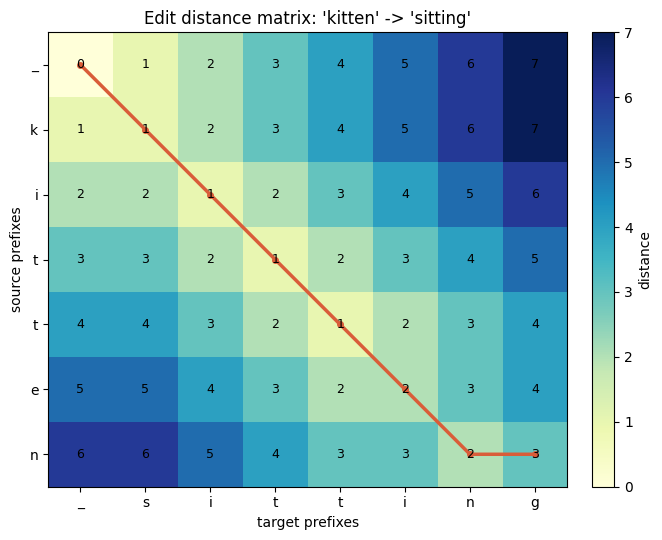

In [4]:
plot_distance_matrix(classic_result)

## 7. Playground: Try Other Pairs

Change the word pairs below. Spell checking and DNA comparison both use the same idea: distance measures how much one sequence must change to become another.

In [5]:
word_pairs = [
    ("flaw", "lawn"),
    ("spell", "spelt"),
    ("GATTACA", "GCATGCU"),
]

for source, target in word_pairs:
    result = LevenshteinSolver(source, target).solve()
    edits = "; ".join(step.describe() for step in result.edit_script())
    print(f"{source!r} -> {target!r}: distance {result.distance}")
    print(f"  edits: {edits}")

'flaw' -> 'lawn': distance 2
  edits: delete 'f'; insert 'n'
'spell' -> 'spelt': distance 1
  edits: substitute 'l' with 't'
'GATTACA' -> 'GCATGCU': distance 4
  edits: substitute 'A' with 'C'; substitute 'T' with 'A'; substitute 'A' with 'G'; substitute 'A' with 'U'


## What You Should Remember

- Levenshtein distance is the minimum number of inserts, deletes, and substitutions needed to transform one string into another.
- The DP table stores answers for prefix-to-prefix problems.
- The first row and first column are base cases: empty string transformations.
- Each inner cell chooses the cheapest of delete, insert, and substitute/match.
- The bottom-right cell is the final distance.
- A traceback through the table gives one optimal edit script.

<details>
<summary>Quick self-check</summary>

If two characters match, the diagonal move costs `0`. If they differ, the diagonal move costs `1`. Insert and delete always cost `1`.
</details>

## Visual Trace + Rigor Studio

**Problem frame.** Find the cheapest edit path between two strings.

**Interactive animation target.** Fill the dynamic-programming matrix cell by cell, highlighting the three predecessor choices.

**Correctness handle.** Every filled cell stores the optimal edit distance for two prefixes.

**Complexity handle.** O(mn) time and O(mn) space, with a space-optimized O(min(m,n)) variant.

**Failure mode to test.** The numeric distance ignores semantic meaning unless paired with a language model or frequency prior.

**Studio task.** Trace three candidate corrections and explain why the best edit distance is not always the best correction.


In [ ]:
from pathlib import Path
import sys
from IPython.display import display

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, levenshtein_trace, render_matrix, render_trace_table

trace = levenshtein_trace("kitten", "sitting")
display(render_trace_table(trace))
AlgorithmPlayer(trace, render_matrix).display()
